# Notes

In [ ]:
# Lower body
    # temporal 
        # every temporal parameter in seconds (later, apart from stride time every other thing should also be calcualted as % of stride time)
        # round temporal parameters to 3 digits
        # double support time has to be rewieved (2 stages for each cycle)

    # spatial
        # every spacial parameter in meters (round to 3 digits)
        # + foot progression angle [deg] (toe in / toe out in gaitrite, only contralateral can be calculated for each gait cycle)
            # at the end it has to be per side
        # foot height during swing (no precise def yet)
        
        # Rotations
        # possibly in 3D, joint/pateient centered coord system
        # ankle angle [deg]
        # knee angle [deg]
        # hip [deg] 

# Upper body
    # spatial
        # trunk ROM 3D [deg] (torsion included)
        # head ROM 3D [deg] (torsion included)
        # arm ROM [deg] in 2 planes (plane of progression, vertical plane tbd)
        # wrist angle [deg] 3D


# a class for every gait parameter
   

# first publication 
    # knee rom 
    # arm swing
    # kinect vs stereo 
    # stat: ICC3 in pingiun table (3rd options)

# Imports

In [1]:
## conda env: stereo_vision
import numpy as np
from rtmlib import draw_skeleton, draw_bbox
from Util.util import *
from Util.calibration_util import *
from Util.gait_util import *
from Util.statistics_util import *
import glob
import time

from dataclasses import dataclass, make_dataclass
from datetime import datetime
from collections import defaultdict
from Util.gait_util import compute_asymmetry

from IPython.display import display, clear_output
from scipy.signal import resample

import pyzed.sl as sl
import matplotlib.pyplot as plt # TODO: get the 5.11 SDK working

# load model info (config, input size, etc)
with open('./Util/2d_model/models.json') as f:
    models = json.load(f)

# load static properties for gait analysis
with open("./Util/gait_analysis_properties.json", "r") as json_file:
    gait_analysis_properties = json.load(json_file)
    stereo_properties = gait_analysis_properties["stereo"]
    qualisys_properties = gait_analysis_properties["qualisys"]

%matplotlib ipympl

# get ZED SDK verison
print(f"ZED SDK: {sl.Camera.get_sdk_version()}")

ZED SDK: 5.0.3


In [59]:
participant = "mate_unger"
# participant = "max_wuehr"
# participant = "irem_tural"
# participant = "sandra_kollmansperger"
# participant = "sophia_grotz"
# participant = "selina_lesigcar"
# participant = "tebarek_abdulhussain"
participant = "vasil_derventliev"


paradigm = "normal_walking"

base_path = os.path.join("validation_test",participant,paradigm)

# Statistics

## Read CSV data 

from all participants for a given task / condition

In [ ]:
parameters = [
    "step_time",
    "step_length",
    "stride_time",
    "stride_length",
    "stride_velocity",
    "swing_time",
    "double_support_time",
    "base_of_support",
]

aggregated_stereo_stats = {}

stats = ['Mean', 'CV', 'Asymmetry']
for metric in parameters:
    for stat in stats:
        inner_dict = {'Mean [m]':[],
                      'CV [%]':[],
                      'Asymmetry [%]':[]
                      }
        aggregated_stereo_stats[metric] = inner_dict

aggregated_qualisys_stats = copy.deepcopy(aggregated_stereo_stats)
statistics_results = copy.deepcopy(aggregated_stereo_stats)


In [ ]:
main_folder = "d:\\munger\\stereolabs_validation\\Code\\StereoVision\\stereo_videos\\validation_test"
# conditions = ["slow_walking","normal_walking","fast_walking"]
conditions = ["normal_walking"]

for condition in conditions:
    for g in glob.glob(f"{main_folder}\\*\\normal_walking\\results\\"):
        participant = g.split("_test\\")[1].split("\\")[0]

        stereo_csv_path = os.path.join(g,f"43916681_{participant}.csv")
        qualisys_csv_path = os.path.join(g, f"qualisys_{participant}.csv")

        if os.path.exists(stereo_csv_path) and os.path.exists(qualisys_csv_path):
            stereo_results = pd.read_csv(stereo_csv_path).to_numpy()
            qualisys_results = pd.read_csv(qualisys_csv_path).to_numpy()

        for row in stereo_results:
            # read the parameter and statistic names along with the values in the "straight_back" perspective column
            parameter, statistic = row[0:2]
            value = row[3]
            aggregated_stereo_stats[parameter][statistic].append(value)

        for row in qualisys_results:
            parameter, statistic = row[0:2]
            value = row[3]
            aggregated_qualisys_stats[parameter][statistic].append(value)

        

In [ ]:
aggregated_stereo_stats
# aggregated_qualisys_stats

In [ ]:
for parameter, statistics_dict in aggregated_qualisys_stats.items():
    for statistic, values in statistics_dict.items():
        print(parameter, statistic, len(values))

In [ ]:
parameters = list(aggregated_qualisys_stats.keys())
statistic_types = list(aggregated_qualisys_stats[parameters[0]].keys())

for parameter in parameters:
    for statistic_type in statistic_types:
        print(
            f"{parameter:<20} {statistic_type:<15} {len(aggregated_qualisys_stats[parameter][statistic_type]):3}, {len(aggregated_stereo_stats[parameter][statistic_type]):3}"
        )
        # statistics_results[parameter][statistic_type] = uniform_statistics(
        #     aggregated_qualisys_stats[parameter][statistic_type],
        #     aggregated_stereo_stats[parameter][statistic_type],
        # )

In [ ]:
uniform_statistics(aggregated_qualisys_stats['step_time']['Mean [m]'], aggregated_stereo_stats['step_time']['Mean [m]'])

In [ ]:
statistics_results

# Stereo preprocessing

In [ ]:
# from export_stereo_video import *

export_svo_avi(
    input_path="D:\\mwuehr\\stereolabs_valdiation\\data\\vasil_derventliev\\stereolabs\\E4F91ED1-FD25-4A0C-BD82-11BC643510E8\\43916681.svo2",
    output_path="D:\\mwuehr\\stereolabs_valdiation\\data\\vasil_derventliev\\stereolabs\\E4F91ED1-FD25-4A0C-BD82-11BC643510E8\\43916681.avi"
)

In [5]:
# from OneEuroFilter import OneEuroFilter
import time


def get_2d_keypoints(video_file_path: str, labels: list) -> np.ndarray:
    """
    Preform 2D pose estimation on RGB video, return x,y pixel coordinates of predicted keypoints.

    Args:
        video_file_path: path of input video
        labels: labels used for indexing keypoints array

    Returns:
        keypoints_2d: array containing the calculated keypoint coordinates. (frames x num_kpts x (x,y))

    """
    # create custom detector & predictor model
    custom_pose_model = load_pose_model()

    print(f"processing: {video_file_path}")

    # containers to store the results in
    keypoints_2d = []
    mid_shoulder = []

    cap = cv2.VideoCapture(video_file_path)
    if cap.isOpened() == False:
        raise FileNotFoundError(f"Error opening video file: {video_file_path}")

    total_num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    processed_num_frames = 0
    start_time = time.time_ns()

    while cap.isOpened():
        ret, frame = cap.read()

        if ret == True and frame is not None:
            processed_num_frames += 1
            width = frame.shape[1]
            height = frame.shape[0]

            # inference
            keypoints, scores = custom_pose_model(frame)

            # visualize
            boxes = [pose_to_bbox(x) for x in keypoints]
            img_show = draw_bbox(frame, boxes, (0, 0, 255))

            # store results (frames * kpt * (x,y)), remove multiperson cases
            if keypoints.shape != (1, 26, 2):
                keypoints = keypoints[0, :, :]
                scores = scores[0, :]

            keypoints = np.squeeze(keypoints)

            # add mid_shoulder keypoint
            left_shouder_position = keypoints[labels.index("left_shoulder")]
            right_shouder_position = keypoints[labels.index("right_shoulder")]
            mid_shoulder_position = np.nanmean(
                [left_shouder_position, right_shouder_position], axis=0
            )

            keypoints_2d.append(keypoints)
            mid_shoulder.append(mid_shoulder_position)

            for kpt in keypoints[:, :]:
                cv2.circle(img_show, (int(kpt[0]), int(kpt[1])), 3, (0, 255, 0), 2)

            cv2.imshow("Image", cv2.resize(img_show, (int(width / 1.5), int(height / 1.5))))

            # display how much time elapsed/is left
            clear_output(wait=True)
            end_time = time.time_ns()
            elapsed_time = (end_time - start_time) / 1000000000

            if int(elapsed_time % 5) == 0:

                fps = round(processed_num_frames / elapsed_time, 2)
                done_ratio = processed_num_frames / total_num_frames
                expected_duration_min = elapsed_time / (done_ratio * 60)

                display(
                    f"exp_duration: {round(expected_duration_min,2)} minutes, elapsed: {round(elapsed_time/60,2)} minutes"
                )
                display(f"done: {round(done_ratio*100,2)}%, fps: {fps}")

            # Press Q on keyboard to exit
            if cv2.waitKey(1) & 0xFF == ord("q"):
                break
        else:
            break
    cap.release()
    cv2.destroyAllWindows()

    keypoints_2d = np.asarray(keypoints_2d)
    mid_shoulder = np.expand_dims(np.array(mid_shoulder), axis=1)
    keypoints_2d = np.hstack((keypoints_2d, mid_shoulder))

    print(f"shape of keypoints_2d:  {keypoints_2d.shape} (frames * kpt * (x, y))")

    return keypoints_2d


# def create_filters(
#     num_keypoints: int, freq: float = 30.0, min_cutoff: float = 1.0, beta: float = 0.0
# ) -> list[OneEuroFilter]:
#     """
#     Create a list of OneEuroFilters for each dimension of a keypoint (x,y,z).

#     Args:
#         num_keypoints: number of keypoints
#         freq: frequency of the time series
#         min_cutoff: min cutoff frequency in Hz
#         beta: parameter to reduce latency

#     Returns:
#         filters: list of OneEuroFilters (num_keypoints,3)
#     """
#     # Create filters for smoothing keypoints
#     filters = []
#     for _ in range(num_keypoints):
#         filters.append(
#             {
#                 "x": OneEuroFilter(freq, min_cutoff, beta),
#                 "y": OneEuroFilter(freq, min_cutoff, beta),
#                 "z": OneEuroFilter(freq, min_cutoff, beta),
#             }
#         )
#     return filters


# def filter_2d_keypoints_euro(keypoints_2d: np.ndarray, freq: float, min_cutoff: float, beta: float):
#     """
#     Filters 2D keypoints using OneEuroFilters. Shape remains the same.
#     """
#     one_euro_filters = create_filters(
#         num_keypoints=keypoints_2d.shape[1], freq=freq, min_cutoff=min_cutoff, beta=beta
#     )
#     keypoints_2d_filtered = []

#     for keypoints_in_frame in keypoints_2d:
#         filtered_keypoints_in_frame = []

#         for kpt_idx, [x, y] in enumerate(keypoints_in_frame):
#             filtered_x = one_euro_filters[kpt_idx]["x"](x)
#             filtered_y = one_euro_filters[kpt_idx]["y"](y)
#             filtered_keypoints_in_frame.append([filtered_x, filtered_y])

#         keypoints_2d_filtered.append(filtered_keypoints_in_frame)
#     keypoints_2d_filtered = np.asarray(keypoints_2d_filtered)
#     return keypoints_2d_filtered


def filter_2d_keypoints_butter(
    keypoints_2d: np.ndarray, order: int = 4, lowcut: float = 2, freq: float = 60
):
    """
    Filter 2D keypoints using butterworth lowpass filter.

    Args:
        keypoints_2d: array containing the input data to be filtered.
        order: order of the butterworth filter. Larger numbers mean steeper response curves.
        lowcut: cutoff value above which frequencies are attenuated
        freq: sampling frequency of the input (60 Hz for stereo)

    Returns: 
        keypoints_2d_filtered: filtered version of the input 
    """
    # container to store results
    keypoints_2d_filtered = []

    # iterate by keypoints
    for keypoint in keypoints_2d.transpose(1, 0, 2):
        filtered_2d_keypoint = filter_2d_keypoint(
            keypoint=keypoint, order=order, lowcut=lowcut, fr=freq, create_diagram=False
        )
        keypoints_2d_filtered.append(filtered_2d_keypoint)

    # transform shape back to original
    keypoints_2d_filtered = np.array(keypoints_2d_filtered).transpose(1, 0, 2)
    return keypoints_2d_filtered


def get_3d_keypoints(keypoints_2d: np.ndarray, svo_file_path: str):
    """
    Get the depth value for each 2D keypoint in the video.

    Args: 
        keypoints_2d: array containing the 2D keypoints which are used to address the depth map created by stereo camera. (frames, num_kpts, dims)
        svo_file_path: path to the .svo2 file that was resorded by the stereo camera.

    Returns: 
        keypoints_3d: 3D keypoints corresponding to the 2D input. (frames, num_keypoints, (x,y,depth))
        Note, only the depth coordinate is in meters, the rest are still pixel values.
    """
    # results container
    keypoints_3d = []

    # create & configure camrea object
    zed = sl.Camera()
    input_type = sl.InputType()
    input_type.set_from_svo_file(svo_file_path)  # Set init parameter to run from the .svo
    init_parameters = sl.InitParameters(input_t=input_type, svo_real_time_mode=False)
    init_parameters.depth_mode = sl.DEPTH_MODE.NEURAL_PLUS
    init_parameters.coordinate_units = sl.UNIT.METER  # CENTIMETER, METER, MILLIMETER
    init_parameters.depth_stabilization = (
        75  # 0 to trun it off, otherwise 1-100 linear. default is 30
    )

    # Open the ZED
    err = zed.open(init_parameters)
    if err != sl.ERROR_CODE.SUCCESS:
        raise Exception(f"Error opening camera obj with svo file: {svo_file_path}")
    svo_depth = sl.Mat()
    svo_image = sl.Mat()

    frame_idx = 0

    while frame_idx < keypoints_2d.shape[0] - 1 and zed.grab() == sl.ERROR_CODE.SUCCESS:

        current_keypoints = []
        frame_idx = zed.get_svo_position()

        # get color image and depth map
        zed.retrieve_measure(svo_depth, sl.MEASURE.DEPTH)
        zed.retrieve_image(svo_image, sl.VIEW.LEFT)  # BGRA image

        img = svo_image.get_data()
        depth_map = svo_depth.get_data()
        depth_map = np.transpose(depth_map)

        # get coords for all keypoints within the current frame
        # note: x,y coords are in pixels, depth is in meters
        for x, y in keypoints_2d[frame_idx, :]:
            depth = depth_map[int(x), int(y)]
            current_keypoints.append(np.array([x, y, depth]))
            cv2.circle(img, (int(x), int(y)), 5, (0, 0, 255), 3)

        current_keypoints = np.array(current_keypoints)
        keypoints_3d.append(current_keypoints)
        cv2.imshow("vid", cv2.resize(img, (800, 600)))

        if cv2.waitKey(25) & 0xFF == ord("q"):
            break

    cv2.destroyAllWindows()
    zed.close()

    keypoints_3d = np.array(keypoints_3d)
    print(f"keypoints 3d shape: {keypoints_3d.shape} (frames, kpts, (x,y,depth))")

    return keypoints_3d


def get_extrinsics(
    calibration_img_path: str, camera_serial_number: str, debug_fig_path: str = None
):
    """
    Get the extrinsic camera parameters using a calibration image and the intrinsic camera parameters. 

    Args: 
        calibration_img_path: path of the calibration image
        camera_serial_number: serial number of the camera, e.g.: SN123456. Used to get the intrinsic parameters for the exact model.
        degub_fig_path: path to save a degub img to 

    Returns: 
        R: rotation matrix
        t_vec: translation vector
    """
    from Util.calibration_util import Pattern, get_image_points

    with open("./Util/camera_params.json", "r") as f:
        intrinsic_params = json.load(f)
        cameraMatrix = np.array(
            intrinsic_params[camera_serial_number]["left_sensor"]["camera_matrix"]
        )
        distCoeffs = np.array(
            intrinsic_params[camera_serial_number]["left_sensor"]["distortion_coeff"]
        )
        f_x = cameraMatrix[0, 0]
        f_y = cameraMatrix[1, 1]
        c_x = cameraMatrix[0, 2]
        c_y = cameraMatrix[1, 2]

    calibration_image = cv2.imread(calibration_img_path, cv2.IMREAD_GRAYSCALE)

    # describe real world calibration pattern parameteres
    board_pattern = Pattern(height=6, width=4, square_size=0.150)

    camera_coords = []

    # get specific points of the image used for calibration, associate them with real-life points of calib pattern
    img_points, obj_points, debug_img = get_image_points(calibration_image, board_pattern)

    # get the transformations describing image-object relationship
    success, rvec, t_vec = cv2.solvePnP(
        obj_points,
        img_points,
        cameraMatrix,
        distCoeffs,
        useExtrinsicGuess=False,
        flags=cv2.SOLVEPNP_ITERATIVE,
    )

    if success:
        R, jac = cv2.Rodrigues(rvec)

        Xw = -np.matrix(R).T * np.matrix(t_vec)
        camera_coords.append(Xw)

        print(f"distance: {round(np.linalg.norm(Xw),2)} m")

    else:
        print(f"{fn}... FAILED")

    # TODO: finish debug img saving
    # if debug_fig_path is not None:
    #     out_file_name =
    #     cv2.imwrite()
    return R, t_vec


def transform_to_global_frame(
    camera_frame_keypoints: np.ndarray, rotation_matrix: np.ndarray, translation_vector: np.ndarray
):
    """
    Transforms 3D keypoints from camera-frame to global-frame using extrinsic parameters obtained by calibration. 
    
    Args:
        camera_frame_keypoints: 3D keypoints represented in camrea based coordinate system
        rotation_matrix: R, currently not used.
        translation_vector: describes translation relative to calibration pattern
    
    Returns:
        keypoints_3d_global_frame: 3D keypoints represented in the global coordinate system. (frames, kpts, (depth, horizontal, vertical))
    
    """
    # TODO: get rid of loading camera params twice
    with open("./Util/camera_params.json", "r") as f:
        intrinsic_params = json.load(f)
        # TODO: replace hardcoded camera serial number
        cameraMatrix = np.array(intrinsic_params["SN43916681"]["left_sensor"]["camera_matrix"])
        f_x = cameraMatrix[0, 0]
        f_y = cameraMatrix[1, 1]
        c_x = cameraMatrix[0, 2]
        c_y = cameraMatrix[1, 2]

    keypoints_3d_global_frame = []

    for kpt in camera_frame_keypoints.transpose(1, 2, 0):
        # camera-frame coordinates
        u = kpt[0, :]
        v = kpt[1, :]
        Zc = kpt[2, :]

        # global/world-frame coordinates
        Xw = ((u - c_x) * Zc / f_x) - translation_vector[0]
        Yw = ((v - c_y) * Zc / f_y) - translation_vector[1]
        Zw = Zc - translation_vector[2]

        # multiply by -1 so axes go in the correct direction
        Yw = -Yw
        Zw = -Zw

        # (depth, horizontal, vertical)
        keypoints_3d_global_frame.append(np.array([Zw, Xw, Yw]))

    keypoints_3d_global_frame = np.array(keypoints_3d_global_frame).transpose(2, 0, 1)

    return keypoints_3d_global_frame


def resample_timeseries(keypoints_3d: np.ndarray, original_fps: float, target_fps: float):
    """
    Resample the input time series data to the desired frequency.

    Args:
        keypoints_3d: 3D keypoints in some coord system
        original_fps: original sampling frequency in Hz of time series
        target_fps: desired sampling frequency

    Returns: 
        resampled_keypoints: keypoint data resampled with the desired frequency
    """
    original_num_frames = keypoints_3d.shape[0]
    target_num_frames = int(np.round(original_num_frames * target_fps / original_fps))

    # pad keypoints along time axis so resample doesnt mess up the ends 
    padded_keypoints_3d = np.pad(array=keypoints_3d,pad_width=((50,50),(0,0),(0,0)),mode="edge")

    resampled_keypoints = resample(padded_keypoints_3d, target_num_frames, axis=0, window=50)
    
    # cut padding off
    resampled_keypoints = resampled_keypoints[50:-50,:,:]
    return resampled_keypoints


def visualize_2d_keypoints(keypoints_2d: np.ndarray, video_path: str) -> None:
    """
    Draw 2D keypoint locations on each frame of RGB video.

    Args:
        keypoints_2d: 2D keypoints to be drawn
        video_path: path to video used to obtain keypoints

    Returns:
        None
    """
    # labels are loaded from static file, only works for stereo 
    labels = models["pose_models"]["26"]["kpt_labels"]

    cap = cv2.VideoCapture(video_path)
    if cap.isOpened() == False:
        print("Error opening video file")

    frame_idx = 0

    # Read until video is completed
    while cap.isOpened() and frame_idx < keypoints_2d.shape[0] - 1:

        # Capture frame-by-frame
        ret, frame = cap.read()

        if ret == True and frame is not None:
            frame_idx += 1
            h, w = frame.shape[:2]

            for kpt_idx, kpt in enumerate(keypoints_2d[frame_idx, :, :]):
                # highlight certain keypoints in green
                if kpt_idx in [
                    labels.index("left_ankle"),
                    labels.index("right_ankle"),
                ]:
                    color = (0, 255, 0)
                else:
                    color = (0, 0, 255)
                cv2.circle(frame, (int(kpt[0]), int(kpt[1])), radius=3, color=color, thickness=2)
            cv2.imshow("Image", cv2.resize(frame, (int(w / 1.5), int(h / 1.5))))
            time.sleep(0.01)

            # Press Q on keyboard to exit
            if cv2.waitKey(1) & 0xFF == ord("q"):
                break
        else:
            break
    cap.release()
    cv2.destroyAllWindows()

In [ ]:
stereo_labels = models["pose_models"]["26"]["kpt_labels"]

# GET 2D KEYPOINTS
video_file_path = os.path.join(base_path, "43916681.avi")
keypoints_2d = get_2d_keypoints(video_file_path=video_file_path, labels=stereo_labels)

# FILTER 2D
keypoints_2d_filtered = filter_2d_keypoints_butter(
    keypoints_2d=keypoints_2d, order=4, lowcut=2, freq=60
)

# GET 3D KEYPOINTS
svo_file_path = os.path.join(base_path, "43916681.svo2")
keypoints_3d = get_3d_keypoints(keypoints_2d=keypoints_2d_filtered, svo_file_path=svo_file_path)

# TRANSFORM TO GLOBAL COORDS
calibraiton_img_path = os.path.join(base_path, "stereo_calibration.png")
R, t = get_extrinsics(calibraiton_img_path, camera_serial_number="SN43916681", debug_fig_path=None)
keypoints_3d = transform_to_global_frame(
    camera_frame_keypoints=keypoints_3d, rotation_matrix=R, translation_vector=t
)

# FILTER 3D KEYPOINTS
keypoints_3d = filter_data(
    data=keypoints_3d.transpose(1, 2, 0),
    sampling_rate=60,
    filter_type="lowpass",
    cutoff=[1.5],
    order=4,
    gap_size=0.25,
).transpose(2, 0, 1)

# RESAMPLE TO 100 Hz
keypoints_3d = resample_timeseries(keypoints_3d=keypoints_3d, original_fps=60, target_fps=100)

# SAVE STEREO DATA
stereo_save_path = os.path.join(base_path, "stereo.npz")

with open(stereo_save_path, "w"):
    np.savez(stereo_save_path, labels=stereo_labels, keypoints=keypoints_3d.transpose(1, 2, 0))
    print(f"keypoints_3d saved to: {stereo_save_path} with shape: {keypoints_3d.shape}")

shape of keypoints_2d:  (3908, 27, 2) (frames * kpt * (x, y))
keypoints 3d shape: (3908, 27, 3) (frames, kpts, (x,y,depth))
corners found: 24
distance: 3.29 m


## Visualization 

In [ ]:
# 2D VISUALIZATION
visualize_2d_keypoints(keypoints_2d=keypoints_2d_filtered, video_path=video_file_path)

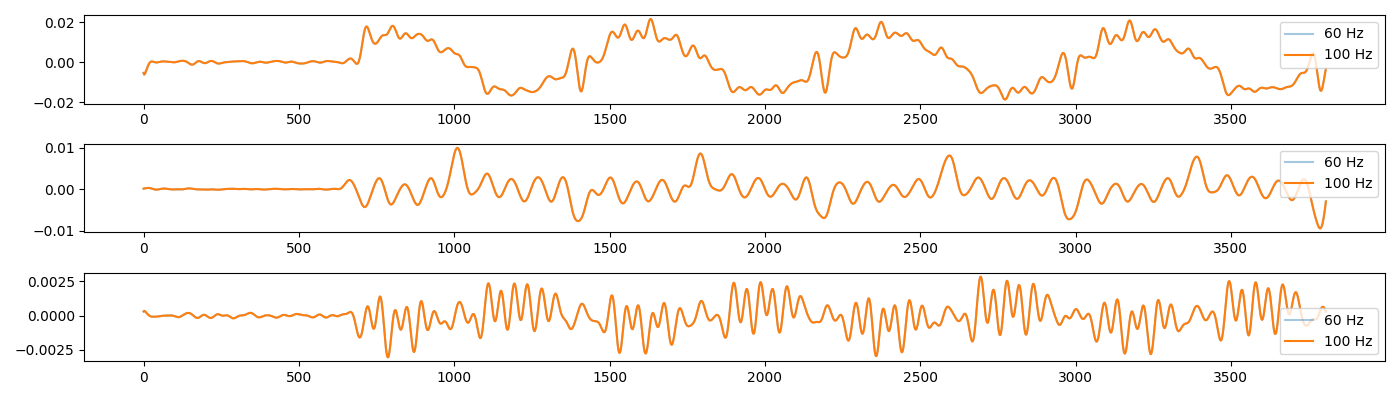

In [7]:
# POSITION PLOT
keypoints_3d_100Hz = resample_timeseries(keypoints_3d=keypoints_3d,original_fps=100,target_fps=100)
r_ankle_idx = stereo_labels.index("right_shoulder")
l_ankle_idx = stereo_labels.index("left_ankle")

fig, axs = plt.subplots(3,1, figsize=(14,4))
axs[0].plot(np.diff(keypoints_3d_100Hz[:,r_ankle_idx,0]), label="60 Hz", alpha=0.4)
axs[1].plot(np.diff(keypoints_3d_100Hz[:,r_ankle_idx,1]), label="60 Hz", alpha=0.4)
axs[2].plot(np.diff(keypoints_3d_100Hz[:,r_ankle_idx,2]), label="60 Hz", alpha=0.4)

axs[0].plot(np.diff(keypoints_3d_100Hz[:,r_ankle_idx,0]), label="100 Hz", )
axs[1].plot(np.diff(keypoints_3d_100Hz[:,r_ankle_idx,1]), label="100 Hz")
axs[2].plot(np.diff(keypoints_3d_100Hz[:,r_ankle_idx,2]), label="100 Hz")
for ax in axs:
    ax.legend()
plt.tight_layout()

In [ ]:
# VELOCITY PLOT (EACH AXIS)
fig, axs = plt.subplots(3,1, figsize=(14,6))
axs[0].plot(np.diff(keypoints_3d_butter[:,r_ankle_idx,0]), label="butter")
axs[0].plot(np.diff(keypoints_3d_euro[:,r_ankle_idx,0]), label="euro")
axs[0].plot(np.diff(qualisys_keypoints[:,r_ankle_idx_q,0]), label="qualisys")

axs[1].plot(np.diff(keypoints_3d_butter[:,r_ankle_idx,1]), label="butter")
axs[1].plot(np.diff(keypoints_3d_euro[:,r_ankle_idx,1]), label="euro")
axs[1].plot(np.diff(qualisys_keypoints[:,r_ankle_idx_q,1]), label="qualisys")

axs[2].plot(np.diff(keypoints_3d_butter[:,r_ankle_idx,2]), label="butter")
axs[2].plot(np.diff(keypoints_3d_euro[:,r_ankle_idx,2]), label="euro")
axs[2].plot(np.diff(qualisys_keypoints[:,r_ankle_idx_q,2]), label="qualisys")


axs[0].set_title("depth")
axs[1].set_title("x")
axs[2].set_title("y")
for ax in axs:
    ax.legend()
plt.tight_layout()

In [ ]:
# 3D VELOCITY PLOT
fig, axs = plt.subplots(2,1, figsize=(14,4))

shift=400

axs[0].plot(np.mean(keypoints_3d_euro[shift:,r_ankle_idx,:],axis=1),label="euro")
axs[0].plot(np.mean(keypoints_3d_butter[shift:,r_ankle_idx,:],axis=1),label="butter")
axs[0].plot(np.mean(qualisys_keypoints[:,r_ankle_idx_q,:],axis=1),label="q")

axs[1].plot(np.diff(np.mean(keypoints_3d_euro[shift:,r_ankle_idx,:],axis=1)),label="euro")
axs[1].plot(np.diff(np.mean(keypoints_3d_butter[shift:,r_ankle_idx,:],axis=1)),label="butter")
axs[1].plot(np.diff(np.mean(qualisys_keypoints[:,r_ankle_idx_q,:],axis=1))[:-200],label="q")


axs[0].set_title("3D position of 1 kpt")
axs[1].set_title("3D velocity of 1 kpt")
for ax in axs:
    ax.legend()
plt.tight_layout()

# Qualisys preprocessing

In [ ]:
tsv_file_path = [g for g in glob.glob(os.path.join(base_path, "*.tsv"))][0]
qualisys_keypoints, qualisys_labels = format_qualisys_export(input_filename=tsv_file_path)
qualisys_keypoints = filter_data(
    data=qualisys_keypoints,
    sampling_rate=100,
    filter_type="lowpass",
    cutoff=[7],
    order=4,
    gap_size=0.25,
)

# SAVE STEREO DATA
qualisys_save_path = os.path.join(base_path, "qualisys.npz")

with open(qualisys_save_path, "w"):
    np.savez(qualisys_save_path, labels=qualisys_labels, keypoints=qualisys_keypoints)
    print(f"qualisys keypoints saved to: {qualisys_save_path} with shape: {qualisys_keypoints.shape}")

# OOP

## Data structures

In [60]:
GAIT_PARAMETERS = [
    "stride_length",
    "stride_time",
    "stride_velocity",
    "base_of_support",
    "double_support_time",
    "swing_time",
    "knee_ext_rom",
    "shoulder_flex_rom",
    "shoulder_abd_rom",
    "elbow_ext_rom",
]

parameters = [(parameter_name, float, np.nan) for parameter_name in GAIT_PARAMETERS]
Parameters = make_dataclass(cls_name="Parameters", fields=parameters)


@dataclass
class GaitEvent:
    def __init__(
        self,
        type: Literal["IC", "FC"] = np.nan,
        frame: int = np.nan,
        side: Literal["left", "right"] = np.nan,
        perspective: Literal["front", "back"] = np.nan,
        segment: Literal["straight", "turn"] = np.nan,
        segment_index: int = np.nan,
        relative_position: float = np.nan,
    ):
        self.type = type
        self.frame = int(frame)
        self.side = side
        self.perspective = perspective
        self.segment = segment
        self.segment_index = segment_index
        self.relative_position = relative_position

    def __repr__(self):
        return f"{self.type:<10}{self.side:<10}{self.frame:<10}{self.perspective:<10}{self.segment:<10}{self.segment_index:<10}{self.relative_position:<10}"

    def print(self):
        string = f"{self.type:<10}{self.side:<10}{self.frame:<10}{self.perspective:<10}{self.segment:<10}{self.segment_index}"
        print(string)


@dataclass
class Flags:
    def __init__(
        self,
    ):
        self.complete_cycle = True  # all gait events are available
        self.types_ok = True  # all gait events are available & have the correct type (IC/FC)
        self.sides_ok = True  # all gait events are available & have the correct sides (right/left)
        self.perspectives_ok = (
            True  # at least IC0, IC2 are available & have the same perspective (front/back)
        )
        self.segments_ok = (
            True  # at least IC0, IC2 are available & have the same segment type (straight, turn)
        )
        self.valid = (
            True  # ge has not been deemed useless, there are no critical mistakes with the ges
        )

    def __str__(self):
        string = f"valid: {self.valid:<5}persp: {self.perspectives_ok:<5}segments: {self.segments_ok:<5}complete cycle: {self.complete_cycle:<5}types: {self.types_ok:<5}sides: {self.sides_ok:<5}"
        return string

    def __repr__(self):
        string = f"valid: {self.valid:<5}persp: {self.perspectives_ok:<5}segments: {self.segments_ok:<5}complete cycle: {self.complete_cycle:<5}types: {self.types_ok:<5}sides: {self.sides_ok:<5}"
        return string


class GaitCycle:
    def __init__(self, input_gait_events: list, keypoint_data: np.ndarray, labels: list, fps):

        self.possible_gait_events = sorted(input_gait_events, key=lambda event: event.frame)
        self.keypoints = keypoint_data
        self.labels = labels
        self.fps = fps

        # IC0, IC2 are determined at the Recording level (checks are also performed there)
        self.IC0 = self.possible_gait_events[0] if len(self.possible_gait_events) >= 2 else None
        self.IC2 = self.possible_gait_events[-1] if len(self.possible_gait_events) >= 2 else None

        self.ipsi = self.IC0.side
        self.contra = "left" if self.ipsi == "right" else "right"
        self.perspective = self.IC0.perspective
        self.segment = self.IC0.segment
        self.segment_index = self.IC0.segment_index
        self.relative_position = self.IC0.relative_position

        # GE priorities (based on parameters): IC0-IC2, IC1, FC0-FC1 -> select IC1 first, then FC0, FC1
        self.IC1 = self.select_gait_event(type="IC", side=self.contra)
        self.FC0 = self.select_gait_event(
            type="FC", side=self.contra, prev_event=self.IC0, next_event=self.IC1
        )
        self.FC1 = self.select_gait_event(
            type="FC", side=self.ipsi, prev_event=self.IC1, next_event=self.IC2
        )

        # get rid of not found / non-existent GEs
        self.gait_events = [
            ge for ge in [self.IC0, self.FC0, self.IC1, self.FC1, self.IC2] if ge is not None
        ]

        self.flags = Flags()
        self.set_flags()

        self.parameters = Parameters()
        if None not in [self.IC0, self.IC2]:
            self.calculate_stride_parameters()

            if self.flags.valid:
                self.calculate_knee_rom()
                self.calculate_elbow_rom()
                self.calculate_shoulder_rom()
                if None not in [self.IC1]:
                    self.calculate_base_of_support()
                    self.calculate_swing_time()
                    if None not in [self.FC0, self.FC1]:
                        self.calculate_double_support_time()

    def __str__(self):
        return f"{self.perspective:<10}{self.ipsi:<10}{self.flags.valid:<10}{[ge.frame for ge in self.gait_events]}"

    def __repr__(self):
        return f"{self.perspective:<10}{self.ipsi:<10}{self.contra:<10}{self.flags.valid:<10}{[ge.frame for ge in self.gait_events]}"

    def calculate_stride_parameters(self) -> None:  # IC0, IC2
        """
        Computes stride_time, stride_lenght and stride_velocity.
            Gait events needed: IC0, IC2

        Sets:
            parameters.stride_time
            parameters.stride_length
            parameters.stride_velocity
        """
        self.parameters.stride_time = (self.IC2.frame - self.IC0.frame) / self.fps

        # IC0_heel = self.keypoints[self.labels.index(f"{self.ipsi}_heel"), :, self.IC0.frame]
        # IC2_heel = self.keypoints[self.labels.index(f"{self.contra}_heel"), :, self.IC2.frame]
        IC0_heel = self.keypoints[self.labels.index(f"{self.ipsi}_ankle"), :, self.IC0.frame]
        IC2_heel = self.keypoints[self.labels.index(f"{self.ipsi}_ankle"), :, self.IC2.frame]
        self.parameters.stride_length = np.linalg.norm(IC2_heel - IC0_heel)

        self.parameters.stride_velocity = (
            self.parameters.stride_length / self.parameters.stride_time
            if self.parameters.stride_time >= 0
            else np.nan
        )

    def calculate_swing_time(self) -> None:  # IC1, IC2
        """
        Computes swing_time.
            Gait events needed: IC1, IC2

        Sets:
            parameters.swing_time
        """
        if self.fps > 0:
            self.parameters.swing_time = (self.IC2.frame - self.IC1.frame) / self.fps

    def calculate_double_support_time(self) -> None:  # FC0, FC1, IC0, IC1
        """
        Computes double_support_time.
            Gait events needed: FC0, FC1, IC0, IC1

        Sets:
            parameters.double_support_time
        """
        if self.fps > 0:
            self.parameters.double_support_time = (
                (self.FC0.frame - self.IC0.frame) + (self.FC1.frame - self.IC1.frame)
            ) / self.fps

    def calculate_base_of_support(self) -> None:  # IC0, IC1, IC2
        """
        Computes base_of_support.
            Gait events needed: IC0, IC1, IC2

        Sets:
            parameters.base_of_support
        """
        # using heels
        # IC1_heel = self.keypoints[self.labels.index(f"{self.contra}_heel"), :, self.IC1.frame]
        # IC0_heel = self.keypoints[self.labels.index(f"{self.ipsi}_heel"), :, self.IC0.frame]
        # IC2_heel = self.keypoints[self.labels.index(f"{self.ipsi}_heel"), :, self.IC2.frame]

        # IC2_IC0_line = IC2_heel - IC0_heel
        # IC0_IC1_line = IC0_heel - IC1_heel

        # using ankles
        IC1_ankle = self.keypoints[self.labels.index(f"{self.contra}_ankle"), :, self.IC1.frame]
        IC0_ankle = self.keypoints[self.labels.index(f"{self.ipsi}_ankle"), :, self.IC0.frame]
        IC2_ankle = self.keypoints[self.labels.index(f"{self.ipsi}_ankle"), :, self.IC2.frame]

        IC2_IC0_line = IC2_ankle - IC0_ankle
        IC0_IC1_line = IC0_ankle - IC1_ankle

        self.parameters.base_of_support = np.linalg.norm(
            np.cross(IC2_IC0_line, IC0_IC1_line)
        ) / np.linalg.norm(IC2_IC0_line)

    def calculate_knee_rom(self) -> None:  # IC0, IC2
        """
        Computes knee range of motion based on extension angle.
            Gait events needed: IC0, IC2

        Sets:
            parameters.knee_ext_rom
        """
        # TODO: figure out which approach is better
        # if it is qualisys recording use the front/back markers according to perspective
        if self.keypoints.shape[0] != 27:
            # hip_position = self.keypoints[self.labels.index(f"{self.ipsi}_hip_{self.perspective}"),:,self.IC0.frame : self.IC2.frame]
            # hip position between ipsi side front and back markers
            hip_front_position = self.keypoints[
                self.labels.index(f"{self.ipsi}_hip_front"), :, self.IC0.frame : self.IC2.frame
            ]
            hip_back_position = self.keypoints[
                self.labels.index(f"{self.ipsi}_hip_front"), :, self.IC0.frame : self.IC2.frame
            ]
            hip_position = np.nanmean([hip_front_position, hip_back_position], axis=0)
        # it is stereo
        else:
            hip_position = self.keypoints[
                self.labels.index(f"{self.ipsi}_hip"), :, self.IC0.frame : self.IC2.frame
            ]

        knee_position = self.keypoints[
            self.labels.index(f"{self.ipsi}_knee"), :, self.IC0.frame : self.IC2.frame
        ]
        ankle_position = self.keypoints[
            self.labels.index(f"{self.ipsi}_ankle"), :, self.IC0.frame : self.IC2.frame
        ]

        # knee ROM
        upper_leg_vector = knee_position - hip_position
        lower_leg_vector = ankle_position - knee_position

        # knee EXTENSION angle for all frames of the current gait-cycle, no projection
        knee_angles = [
            angle_between_vectors(lower_leg, upper_leg)
            for lower_leg, upper_leg in zip(lower_leg_vector.T, upper_leg_vector.T)
        ]
        # knee range of motion = max(knee angle) - min(knee angle) in given gait cycle
        self.parameters.knee_ext_rom = np.ptp(knee_angles)
        self.knee_ext_angles = knee_angles

    def calculate_elbow_rom(self) -> None:  # IC0, IC2
        """
        Computes elbow range of motion based on flexion angle.
            Gait events needed: IC0, IC2

        Sets:
            parameters.elbow_ext_rom
        """
        shoulder_position = self.keypoints[
            self.labels.index(f"{self.contra}_shoulder"), :, self.IC0.frame : self.IC2.frame
        ]
        elbow_position = self.keypoints[
            self.labels.index(f"{self.contra}_elbow"), :, self.IC0.frame : self.IC2.frame
        ]
        wrist_position = self.keypoints[
            self.labels.index(f"{self.contra}_wrist"), :, self.IC0.frame : self.IC2.frame
        ]

        # arm rom (elbow flexion, shoulder flexion, shoulder adduction)
        upper_arm_vector = elbow_position - shoulder_position
        lower_arm_vector = wrist_position - elbow_position

        # elbow flexion angle w/o projection
        elbow_angles = [
            angle_between_vectors(upper_arm, lower_arm)
            for upper_arm, lower_arm in zip(upper_arm_vector.T, lower_arm_vector.T)
        ]
        self.elbow_ext_angles = elbow_angles
        self.parameters.elbow_ext_rom = np.ptp(elbow_angles)

    def calculate_shoulder_rom(self) -> None:  # IC0, IC2
        """
        Computes shoulder range of motion based on flexion/extension angle.
            Shoulder flexion/extension: angle between torso vector (mid_shoulder-mid_hip) and upper arm (shoulder-elbow) projections in sagittal plane.
            Shoulder adduction/abduction: angle between shoulder vector (left_shoulder-right_shoulder) and upper arm (shoulder-elbow) projections in coronal plane.
        Gait events needed: IC0, IC2

        Sets:
            parameters.shoulder_flex_rom
            parameters.shoulder_abd_rom
            self.shoulder_flex_angles
            self.shoulder_abd_angles
        """
        contra_shoulder_position = self.keypoints[
            self.labels.index(f"{self.contra}_shoulder"), :, self.IC0.frame : self.IC2.frame
        ]
        ipsi_shoulder_position = self.keypoints[
            self.labels.index(f"{self.ipsi}_shoulder"), :, self.IC0.frame : self.IC2.frame
        ]
        elbow_position = self.keypoints[
            self.labels.index(f"{self.contra}_elbow"), :, self.IC0.frame : self.IC2.frame
        ]
        mid_shoulder_position = self.keypoints[
            self.labels.index(f"mid_shoulder"), :, self.IC0.frame : self.IC2.frame
        ]

        # if it is qualisys recording use the front/back markers according to perspective
        if self.keypoints.shape[0] != 27:
            mid_hip_position = self.keypoints[
                self.labels.index(f"mid_hip_{self.perspective}"), :, self.IC0.frame : self.IC2.frame
            ]
        # it is stereo
        else:
            mid_hip_position = self.keypoints[
                self.labels.index(f"mid_hip"), :, self.IC0.frame : self.IC2.frame
            ]

        upper_arm_vector = elbow_position - contra_shoulder_position
        torso_vector = mid_hip_position - mid_shoulder_position

        sagittal_normal = contra_shoulder_position - ipsi_shoulder_position
        coronal_normal = np.cross(sagittal_normal.T, torso_vector.T)

        # shoulder flexion/extension angle with projection (torso and upper arm on sagittal plane)
        sagittal_upper_arm_proj = get_projection(sagittal_normal, upper_arm_vector)
        sagittal_torso_proj = get_projection(sagittal_normal, torso_vector)
        shoulder_flex_angles = np.array(
            [
                angle_between_vectors(upper_arm_proj, torso_proj)
                for upper_arm_proj, torso_proj in zip(sagittal_upper_arm_proj, sagittal_torso_proj)
            ]
        )
        self.parameters.shoulder_flex_rom = np.ptp(shoulder_flex_angles)
        self.shoulder_flex_angles = shoulder_flex_angles

        # shoulder abduction/adduction angle with projection (torso and upper arm on coronal plane)
        coronal_torso_proj = get_projection(coronal_normal.T, torso_vector)
        coronal_arm_proj = get_projection(coronal_normal.T, upper_arm_vector)
        shoulder_abd_angles = [
            angle_between_vectors(torso_proj, upper_arm_proj)
            for torso_proj, upper_arm_proj in zip(coronal_torso_proj, coronal_arm_proj)
        ]
        self.parameters.shoulder_abd_rom = np.ptp(shoulder_abd_angles)
        self.shoulder_abd_angles = shoulder_abd_angles

    def set_flags(self) -> None:
        """
        Checks the perspectives (front/back), segments (straight/turn), types (IC/FC), sides (left/right) of gait cycle.

        Sets:
            flags.perspectives_ok
            flags.segments_ok
            flags.types_ok
            flags.sides_ok
            flags.complete_cycle
            flags.valid
        """

        # check if perspectives are all the same (front/back)
        self.flags.perspectives_ok = False not in [
            ge.perspective == self.perspective for ge in self.gait_events
        ]
        # check if segments are all the same (straight/turn)
        self.flags.segments_ok = False not in [
            ge.segment == self.segment and ge.segment_index == self.segment_index
            for ge in self.gait_events
        ]

        self.flags.types_ok = False not in [
            self.IC0.type == "IC" if self.IC0 is not None else True,
            self.FC0.type == "FC" if self.FC0 is not None else True,
            self.IC1.type == "IC" if self.IC1 is not None else True,
            self.FC1.type == "FC" if self.FC1 is not None else True,
            self.IC2.type == "IC" if self.IC2 is not None else True,
        ]
        self.flags.sides_ok = False not in [
            self.IC0.side == self.ipsi if self.IC0 is not None else True,
            self.FC0.side == self.contra if self.FC0 is not None else True,
            self.IC1.side == self.contra if self.IC1 is not None else True,
            self.FC1.side == self.ipsi if self.FC1 is not None else True,
            self.IC2.side == self.ipsi if self.IC2 is not None else True,
        ]

        # if we have all gait events
        if None not in [self.IC0, self.IC1, self.IC2, self.FC0, self.FC1]:
            # get rid of the rest (extra events)
            self.gait_events = sorted(
                [self.IC0, self.IC1, self.IC2, self.FC0, self.FC1], key=lambda event: event.frame
            )
        else:
            self.flags.complete_cycle = False

        if (
            not self.flags.types_ok
            or not self.flags.sides_ok
            or not self.flags.perspectives_ok
            or not self.flags.segments_ok
        ):
            self.flags.valid = False

    def select_gait_event(
        self,
        type: Literal["IC", "FC"],
        side: Literal["left", "right"],
        prev_event: GaitEvent = None,
        next_event: GaitEvent = None,
    ) -> GaitEvent | None:
        """
        Select the appropriate gait event from the possible_gait_events belonging to this gait cycle.

        Args:
            type: type of gait event
            side: side of gait event
            prev_event: previoius GE event (based on frame). Selected GE can only come after this
            next_event: next GE event. Selected one must come before this.

        Returns:
            selected_gait_event: the first event (ranked by frame) that satisfies the criteria, otherwise None
        """

        frame_min = prev_event.frame if prev_event is not None else self.IC0.frame
        frame_max = next_event.frame if next_event is not None else self.IC2.frame

        specified_gait_events = [
            ge
            for ge in self.possible_gait_events
            if (
                ge.type == type
                and ge.side == side
                and ge.perspective == self.perspective
                and ge.segment == self.segment
                and frame_min <= ge.frame <= frame_max
            )
        ]
        selected_gait_event = next(iter(specified_gait_events), None)
        return selected_gait_event

    def print(self):
        string = f"{self.perspective:<10}{self.ipsi:<10}{self.contra:<10}{self.valid:<10}{[ge.frame for ge in self.gait_events]}   {self.parameters}"
        print(string)


class Recording:
    def __init__(
        self,
        keypoints: np.ndarray,
        labels,
        recording_type: Literal["stereo", "qualisys"],
        gait_analysis_properties: dict,
        debug_folder: str = None,
    ):
        self.keypoints = keypoints
        self.labels = labels
        self.recording_type = recording_type

        # gait analysis properties
        gait_analysis_properties = gait_analysis_properties[self.recording_type]
        self.fps = gait_analysis_properties["fps"]
        self.max_gap = gait_analysis_properties["max_gap_interpolation"]
        self.filter_cutoff = gait_analysis_properties["filter_cutoff"]
        self.filter_order = gait_analysis_properties["filter_order"]

        self.heel_thr = gait_analysis_properties["heel_thr"]
        self.toe_thr = gait_analysis_properties["toe_thr"]

        self.min_stride_time = gait_analysis_properties["stride_time_min"] * self.fps
        self.max_stride_time = gait_analysis_properties["stride_time_max"] * self.fps
        self.min_swing_time = gait_analysis_properties["swing_time_min"] * self.fps
        self.min_stance_time = gait_analysis_properties["stance_time_min"] * self.fps

        if not os.path.exists(debug_folder):
            os.mkdir(debug_folder)
        self.debug_folder = debug_folder

        self.turn_mask, self.perspective, self.segment_indices, self.segment_boundaries = (
            self.get_turns_and_perspective_and_segments()
        )

        if self.perspective[0] != "front":
            self.keypoints[:, 1, :] = self.keypoints[:, 1, :] * (-1)
            self.turn_mask, self.perspective, self.segment_indices, self.segment_boundaries = (
                self.get_turns_and_perspective_and_segments()
            )

        self.initial_gait_events = self.get_gait_events(velocity=1, create_debug_fig=False)
        self.initial_gait_cycles = self.get_gait_cycles(self.initial_gait_events)
        self.velocity_estimate = np.nanmean(
            [gc.parameters.stride_velocity for gc in self.initial_gait_cycles if gc.flags.valid]
        )
        self.gait_events = self.get_gait_events(
            velocity=self.velocity_estimate, create_debug_fig=True
        )
        # make distinction between valid and all-gait cycles
        self.all_gait_cycles = self.get_gait_cycles(self.gait_events)
        self.gait_cycles = [gc for gc in self.all_gait_cycles if gc.flags.valid]
        if self.debug_folder is not None:
            self.create_gait_cycles_figure()

    def get_gait_cycles(self, gait_events: list):
        gait_cycles = []
        for event in gait_events:
            if event.type == "IC":
                next_ipsi_IC = next(
                    iter(
                        [
                            ge
                            for ge in gait_events
                            if (
                                ge.type == "IC"
                                and ge.side == event.side
                                and ge.frame > event.frame
                                and ge.frame <= event.frame + self.max_stride_time
                                and ge.perspective == event.perspective
                                and ge.segment == event.segment
                            )
                        ]
                    ),
                    None,
                )
                if next_ipsi_IC is not None:
                    possible_events = [
                        ge
                        for ge in gait_events
                        if (ge.frame >= event.frame and ge.frame <= next_ipsi_IC.frame)
                    ]
                    current_gait_cycle = GaitCycle(
                        possible_events, self.keypoints, self.labels, self.fps
                    )
                    gait_cycles.append(current_gait_cycle)

        return gait_cycles

    def get_turns_and_perspective_and_segments(
        self,
        min_peak_height: float = 0.25,
        relative_height: float = 0.85,
        min_walk_duration: float = 2,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict]:
        """
        Identifies turning segments (straight/turn) and perspective (front / back) based on shoulder coordinates using peak detection method.
        Also assigns numeric indices to segments (0,1,2...) and records segment boundaries based on perspective.

        Args:
            min_peak_height:    only peaks above this height will be considered
            relative_height:    height at which the bases of a peak will be taken. It is MEASURED FROM APEX
            min_walk_duration:  min elapsed time (in seconds) between turns (1 turn = 180 deg)

        Returns:
            turn_mask: boolean array indicating straight turning segments (1) and straight segments (0).

            perspective: bollean array indicating frontal facing (1) and back facing (0) segments.

            segment_indices: array containing the segment index for every time point.

            segment_boundaries: dict linking segent indices to segment bondaries. (idx 1-> 0-1500)
        """
        # get the y coord of shoulders (for qualisys x-y plane is horizontal, y coord was forwards/backwards movement)
        shoulder_R = self.keypoints[self.labels.index("right_shoulder"), 1, :]
        shoulder_L = self.keypoints[self.labels.index("left_shoulder"), 1, :]

        # normalize signal
        shoulder_diff = np.abs(
            np.diff(shoulder_R - shoulder_L, prepend=(shoulder_R - shoulder_L)[0])
        )
        shoulder_diff = shoulder_diff / np.nanmax(shoulder_diff)

        # Interpolate NaNs in shoulder_diff
        if np.any(np.isnan(shoulder_diff)):
            nans = np.isnan(shoulder_diff)
            shoulder_diff[nans] = np.interp(
                np.flatnonzero(nans), np.flatnonzero(~nans), shoulder_diff[~nans]
            )

        # min distance from peak to peak (2 seconds of straight movement) in samples
        min_peak_distance = min_walk_duration * self.fps

        peaks, peak_properties = find_peaks(
            shoulder_diff, height=min_peak_height, distance=min_peak_distance
        )
        widths, width_heights, left_ips, right_ips = peak_widths(
            x=shoulder_diff, peaks=peaks, rel_height=relative_height
        )

        # create mask to indicate straight walking segments (straight=False, turn=True)
        turn_mask = np.zeros_like(shoulder_R)
        for left_base_idx, right_base_idx in zip(
            np.floor(left_ips).astype(int), np.ceil(right_ips).astype(int)
        ):
            # turn_segment_length = right_base_idx - left_base_idx
            turn_mask[left_base_idx:right_base_idx] = 1

        # create mask to indicate front vs back perspectives (front=True, back=False)
        perspective = np.where(shoulder_L > shoulder_R, "front", "back")
        turn_mask = np.where(turn_mask == 1, "turn", "straight")

        # assign indices to straight segments
        numeric_perspective = np.where(shoulder_L > shoulder_R, 1, 0)
        perspective_change = np.diff(a=numeric_perspective, prepend=[numeric_perspective[0]])
        segment_idx = 0
        segment_idices = np.empty_like(perspective_change)
        for frame_idx, change in enumerate(perspective_change):
            if change != 0:
                segment_idx += 1
            segment_idices[frame_idx] = segment_idx

        # record boundary indices of segments
        segment_boundary_indices = np.concat(
            ([0], np.flatnonzero(perspective_change), [len(perspective_change)])
        )
        segment_boundaries = {}
        for idx, boundary in enumerate(segment_boundary_indices):
            if idx < len(segment_boundary_indices) - 1:
                segment_boundaries[idx] = [boundary, segment_boundary_indices[idx + 1]]

        # PLOT
        if self.debug_folder is not None:

            plt.close("all")
            fig, axs = plt.subplots(4, 1, figsize=(14, 6))

            axs[0].plot(shoulder_diff, label="shoulder diff")
            axs[0].plot(left_ips, width_heights, "o", label="turn start", markersize=4)
            axs[0].plot(right_ips, width_heights, "o", label="turn end", markersize=4)
            axs[0].plot(turn_mask, label="straight/turn")
            axs[0].set_title("turn mask")

            axs[1].plot(shoulder_L, label="left")
            axs[1].plot(shoulder_R, label="right")
            axs[1].set_title("shoulder position (horizontal)")

            axs[2].plot(perspective, label="perspective")

            axs[2].set_title("Perspective")

            axs[3].plot(segment_idices, label="segment indices")
            axs[3].set_title("segment indices")
            axs[3].set_xlabel("Time [samples]")

            for ax in axs[:-2]:
                ax.legend(loc="upper left")
                ax.grid()

            plt.tight_layout()

            out_filename = os.path.join(
                self.debug_folder, f"{self.recording_type}_turns_and_perspective.png"
            )
            plt.savefig(out_filename)

            print(f"TPS figure saved to: \n{out_filename}")

        return (turn_mask, perspective, segment_idices, segment_boundaries)

    def get_gait_events(self, velocity, create_debug_fig: bool = False):
        heel_thr = self.heel_thr * velocity
        ankle_thr = self.heel_thr * velocity
        big_toe_thr = self.toe_thr * velocity

        all_events = []

        for side in ["left", "right"]:
            heel = self.keypoints[self.labels.index(f"{side}_heel"), :, :]
            big_toe = self.keypoints[self.labels.index(f"{side}_big_toe"), :, :]
            ankle = self.keypoints[self.labels.index(f"{side}_ankle"), :, :]

            heel_vel = (
                np.linalg.norm(np.diff(heel, axis=1, prepend=heel[:, [0]]), axis=0) * self.fps
            )
            ankle_vel = (
                np.linalg.norm(np.diff(ankle, axis=1, prepend=ankle[:, [0]]), axis=0) * self.fps
            )
            big_toe_vel = (
                np.linalg.norm(np.diff(big_toe, axis=1, prepend=big_toe[:, [0]]), axis=0) * self.fps
            )

            # ground_contact_thrs = (
            #     (heel_vel < heel_thr) | (ankle_vel < ankle_thr) | (big_toe_vel < big_toe_thr)
            # ).astype(int)
            ground_contact_thrs = (ankle_vel < ankle_thr).astype(int)

            # remove events from turn segments
            ground_contact_straight = np.where(self.turn_mask == "straight", ground_contact_thrs, 1)

            contact_diff_straight = np.diff(
                ground_contact_straight, prepend=ground_contact_straight[0]
            )

            # remove too short swing periods
            ground_conact_no_short_swing = np.copy(ground_contact_straight)
            starts = np.nonzero(contact_diff_straight == -1)[0]
            ends = np.nonzero(contact_diff_straight == 1)[0]

            for start_frame, end_frame in zip(starts, ends):
                if end_frame - start_frame < self.min_swing_time:
                    ground_conact_no_short_swing[start_frame:end_frame] = 1

            contact_diff_no_short_swing = np.diff(
                ground_conact_no_short_swing, prepend=ground_conact_no_short_swing[0]
            )

            # remove too short contact periods
            ground_contact_no_short_contact = np.copy(ground_conact_no_short_swing)
            starts = np.nonzero(contact_diff_no_short_swing == 1)[0]
            ends = np.nonzero(contact_diff_no_short_swing == -1)[0]
            for idx, [start_frame, end_frame] in enumerate(zip(starts, ends)):
                if idx + 1 < ends.shape[0]:
                    if ends[idx + 1] - start_frame < self.min_stance_time:
                        ground_contact_no_short_contact[start_frame : ends[idx + 1]] = 0

            contact_diff_no_short_contact = np.diff(
                ground_contact_no_short_contact, prepend=ground_contact_no_short_contact[0]
            )

            IC_frames = np.nonzero(contact_diff_no_short_contact == 1)[0]
            FC_frames = np.nonzero(contact_diff_no_short_contact == -1)[0]

            IC_events = [
                GaitEvent(
                    type="IC",
                    frame=frame,
                    side=side,
                    perspective=self.perspective[frame],
                    segment=self.turn_mask[frame],
                    segment_index=self.segment_indices[frame],
                    relative_position=self.calculate_relative_position(frame_idx=frame),
                )
                for frame in IC_frames
            ]

            FC_events = [
                GaitEvent(
                    type="FC",
                    frame=frame,
                    side=side,
                    perspective=self.perspective[frame],
                    segment=self.turn_mask[frame],
                    segment_index=self.segment_indices[frame],
                    relative_position=self.calculate_relative_position(frame_idx=frame),
                )
                for frame in FC_frames
                if frame < len(self.turn_mask)
            ]

            all_events.extend(IC_events + FC_events)

            # PLOT
            if create_debug_fig:
                plt.close("all")
                fig, axs = plt.subplots(4, 1, figsize=(14, 7))

                axs[0].plot(ankle_vel, label="velocity")
                axs[0].plot(ground_contact_thrs * ankle_thr, label="ground contact at thr")
                # axs[0].plot(self.turn_mask,'r--')

                axs[1].plot(ground_contact_thrs + 6, label="raw", color="#ff8800ff")
                axs[1].plot(ground_contact_straight + 4, label="no turns", color="#ffd000ff")
                axs[1].plot(
                    ground_conact_no_short_swing + 2, label="no short swings", color="#d9e717"
                )
                axs[1].plot(
                    ground_contact_no_short_contact, label="no short contacts", color="#6dc916"
                )

                axs[2].plot(contact_diff_straight + 4, label="no turns", color="#ffd000ff")
                axs[2].plot(
                    contact_diff_no_short_swing + 2, label="no short swings", color="#d9e717"
                )
                axs[2].plot(
                    contact_diff_no_short_contact, label="no short contact", color="#6dc916"
                )

                axs[3].plot(self.perspective, label="perspective")

                # fmt: off
                axs[0].set_title("ankle velocity")
                axs[1].set_title("ground contact")
                axs[2].set_title("ground contact diff (GEs)")

                axs[0].set_yticks([0, 3, ankle_thr])
                axs[0].set_ylim([0,3])
                # fmt: on
                for ax in axs:
                    ax.legend(loc="upper left")
                    ax.grid()

                plt.tight_layout()
                out_filename = os.path.join(
                    self.debug_folder, f"{self.recording_type}_gait_events_{side}.png"
                )
                plt.savefig(out_filename)
                plt.close("all")
                print(f"GE figure saved to: \n{out_filename}")
        all_events_sorted = sorted(all_events, key=lambda event: event.frame)

        return all_events_sorted

    def create_gait_cycles_figure(self):
        if self.debug_folder is not None:
            plt.close("all")
            fig, axs = plt.subplots(3, 1, figsize=(14, 5))

            # show GEs of all gait cycles
            for gc in self.all_gait_cycles:
                alpha = 1 if gc.flags.valid else 0.25
                if gc.IC0 != None:
                    axs[0].vlines(gc.IC0.frame, 0, 0.9, "c", linewidth=3, alpha=alpha)
                if gc.IC2 != None:
                    axs[0].vlines(gc.IC0.frame, 1.1, 1.9, "m", linewidth=3, alpha=alpha)
                if gc.IC1 != None:
                    axs[0].vlines(gc.IC0.frame, 2.1, 2.9, "r", linewidth=3, alpha=alpha)
                if gc.FC1 != None:
                    axs[0].vlines(gc.IC0.frame, 3.1, 3.9, "b", linewidth=3, alpha=alpha)
                if gc.FC0 != None:
                    axs[0].vlines(gc.IC0.frame, 4.1, 4.9, "g", linewidth=3, alpha=alpha)

            axs[0].set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], ["IC0", "IC2", "IC1", "FC1", "FC0"])
            axs[0].set_xlim([0, len(self.perspective)])
            axs[0].set_title("gait cycle composition")

            # show flags of all gait cycles
            for gc in self.all_gait_cycles:
                if gc.flags.valid:
                    axs[1].vlines(gc.IC0.frame, 0, 0.9, "gray", linewidth=3)
                if gc.flags.perspectives_ok:
                    axs[1].vlines(gc.IC0.frame, 1.1, 1.9, "gray", linewidth=3)
                if gc.flags.segments_ok:
                    axs[1].vlines(gc.IC0.frame, 2.1, 2.9, "gray", linewidth=3)
                if gc.flags.types_ok:
                    axs[1].vlines(gc.IC0.frame, 3.1, 3.9, "gray", linewidth=3)
                if gc.flags.sides_ok:
                    axs[1].vlines(gc.IC0.frame, 4.1, 4.9, "gray", linewidth=3)

            axs[1].set_yticks(
                [0.5, 1.5, 2.5, 3.5, 4.5], ["valid", "persp", "segments", "types", "sides"]
            )
            axs[1].set_xlim([0, len(self.perspective)])
            axs[1].set_title("gait cycle flags")

            axs[2].plot(self.perspective)
            axs[2].plot(self.turn_mask)
            axs[2].set_xlim([0, len(self.perspective)])

            plt.tight_layout()
            # plt.show()

            out_filename = os.path.join(self.debug_folder, f"{self.recording_type}_gait_cycles.png")
            plt.savefig(out_filename)
            print(f"Gait cycles figure saved to: \n{out_filename}")

    def calculate_relative_position(self, frame_idx: int) -> float:
        """
        Calculates the relative (compared to segment end) position of GE within the segment it belongs to.
        Note: segment end is used as reference, since the length of the first segment (idx 0) can have significantly different length in stereo/qualisys

        Args:
            frame_idx: frame of the GE

        Returns:
            relative_position: position of GE's frame within the segment defined by self.segment_boundaries
        """
        for segment_idx, (start, end) in self.segment_boundaries.items():
            if start < frame_idx < end:
                segment_length = end - start
                relative_position = (end - frame_idx) / segment_length
                return relative_position


class RecordingPair:

    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.qualisys_file_path = os.path.join(folder_path, "qualisys.npz")
        self.stereo_file_path = os.path.join(folder_path, "stereo.npz")
        self.debug_folder_path = os.path.join(folder_path, "Results")

        qualisys_keypoints, qualisys_labels = load_keypoints_and_labels(self.qualisys_file_path)
        stereo_keypoints, stereo_labels = load_keypoints_and_labels(self.stereo_file_path)
        
        self.qualisys = Recording(
            keypoints=qualisys_keypoints,
            labels=qualisys_labels,
            recording_type="qualisys",
            gait_analysis_properties=gait_analysis_properties,
            debug_folder=self.debug_folder_path,
        )
        self.stereo = Recording(
            keypoints=stereo_keypoints,
            labels=stereo_labels,
            recording_type="stereo",
            gait_analysis_properties=gait_analysis_properties,
            debug_folder=self.debug_folder_path,
        )
        self.get_sync_pairs()
        self.create_sync_figure()

        self.statistics_results = self.create_result_container()
        self.get_statistics_results()
        self.save_statistics_results()

    def get_sync_pairs(self):

        gc_pairs = []
        stereo_first_turn = np.where(self.stereo.turn_mask == "turn")[0][0]
        qualisys_first_turn = np.where(self.qualisys.turn_mask == "turn")[0][0]
        shift = stereo_first_turn - qualisys_first_turn

        qualisys_gcs = np.copy(self.qualisys.gait_cycles).tolist()
        for gc in self.stereo.gait_cycles:
            potential_pairs = [
                p
                for p in qualisys_gcs
                if p.segment_index == gc.segment_index
                and p.ipsi == gc.ipsi
                and p.perspective == gc.perspective
            ]
            # there are potential pair found
            if len(potential_pairs) != 0:

                if gc.segment_index != 0:
                        # calculate difference between relative positions (position within segment), choose closest one
                        best_pair_idx = np.argmin(
                            [abs(gc.relative_position - p.relative_position) for p in potential_pairs]
                        )
                else: 
                    # calculate difference between absolute positions. 
                    # Needed since recordings start at different times, first segments have different lengths which throws off relative calculaiton. 
                    stereo_segment_end = self.stereo.segment_boundaries[0][1]
                    stereo_absolute_position = stereo_segment_end - gc.IC0.frame

                    qualisys_segment_end = self.qualisys.segment_boundaries[0][1]
                    best_pair_idx = np.argmin(
                        [abs(stereo_absolute_position - (qualisys_segment_end - p.IC0.frame)) for p in potential_pairs]
                    )

                choosen_pair = potential_pairs[best_pair_idx]
                gc_pairs.append([gc, choosen_pair])
                
                # remove choosen pair from pool potential pairs of the rest
                qualisys_gcs.remove(choosen_pair)

        self.sync_pairs = np.asarray(gc_pairs)
        self.sync_shift = shift

    def create_sync_figure(self):
        plt.close("all")
        fig, axs = plt.subplots(2, 1, figsize=(14, 3))

        # plot turn masks
        axs[0].plot(self.stereo.turn_mask[self.sync_shift:], color="#000000", alpha=0.9,linestyle='-')
        axs[1].plot(self.qualisys.turn_mask, color="#000000", alpha=0.9,linestyle='-')

        # plot valid GCs for both recording types
        for stereo_gc, qualisys_gc in zip(self.stereo.gait_cycles, self.qualisys.gait_cycles):
            axs[0].vlines(x=stereo_gc.IC0.frame - self.sync_shift, ymin=0, ymax=1, color="#138BDB76")
            axs[1].vlines(x=qualisys_gc.IC0.frame, ymin=0, ymax=1, color="#138BDB76")

        # plot pairs 
        colors = plt.get_cmap("prism", int(len(self.sync_pairs)))
        for color_idx, (stereo_gc, qualisys_gc) in enumerate(self.sync_pairs): 
            axs[0].vlines(x=stereo_gc.IC0.frame-self.sync_shift, ymin=0, ymax=1, color=colors(color_idx), linewidth=4)
            axs[1].vlines(x=qualisys_gc.IC0.frame, ymin=0, ymax=1, color=colors(color_idx), linewidth=4)

        axs[0].set_title("stereo")
        axs[1].set_title("qualisys")
        axs[0].set_xlim([0, self.qualisys.keypoints.shape[2]])
        axs[1].set_xlim([0, self.qualisys.keypoints.shape[2]])
        axs[1].set_xlabel("Time [samples]")

        plt.tight_layout()
        out_filename = os.path.join(self.debug_folder_path, f"sync.png")
        plt.savefig(out_filename)
        print(f"Sync figure saved to: \n{out_filename}")

    def create_result_container(self):
        metrics = {"mean": np.nan, "std": np.nan, "cv": np.nan, "asymmetry": np.nan}

        # statistics_results = {}
        # for perspective in ["front","back"]:

        #     recording_results = {}
        #     for recording_type in ["qualisys", "stereo"]:
        #         parameter_results = {}
        #         for parameter in GAIT_PARAMETERS:
        #             parameter_results[parameter] = {}
        #         recording_results[recording_type] = parameter_results
        #     statistics_results[perspective] = recording_results

        # return statistics_results
        nested_dict = lambda: defaultdict(nested_dict)
        statistics_results = nested_dict()
        for perspective in ["front", "back"]:
            for recording_type in ["qualisys", "stereo"]:
                for parameter in GAIT_PARAMETERS:
                    statistics_results[perspective][recording_type][parameter] = {}
        return statistics_results

    def get_statistics_results(self):
        """
        Calculates metrics for stereo and qualisys gait cycles present in self.sync_pairs for different perspectives.
        """
        for perspective in ["front", "back"]:
            for parameter in GAIT_PARAMETERS:
                for type_idx, recording_type in enumerate(["stereo", "qualisys"]):

                    values_left = [
                        getattr(gc.parameters, parameter, np.nan)
                        for gc in self.sync_pairs[:, type_idx]
                        if gc.perspective == perspective and gc.ipsi == "left"
                    ]
                    values_right = [
                        getattr(gc.parameters, parameter, np.nan)
                        for gc in self.sync_pairs[:, type_idx]
                        if gc.perspective == perspective and gc.ipsi == "right"
                    ]

                    values_all = np.concat((values_left, values_right))
                    mean = np.nanmean(values_all)
                    std = np.nanstd(values_all)
                    cv = 100 * std / mean if mean != 0 else np.nan
                    asymmetry = compute_asymmetry(values_left, values_right)

                    metrics = {"mean": mean, "std": std, "cv": cv, "asymmetry": asymmetry}

                    self.statistics_results[perspective][recording_type][parameter] = metrics

    def print_statistics_results(self):
        stat = self.statistics_results
        rows = []
        for (parameter_name, qualisys_front), stereo_front, qualisys_back, stereo_back in zip(
            stat["front"]["qualisys"].items(),
            stat["front"]["stereo"].values(),
            stat["back"]["qualisys"].values(),
            stat["back"]["stereo"].values(),
        ):
            for (
                (metric_name, qualisys_front_value),
                stereo_front_value,
                qualisys_back_value,
                stereo_back_value,
            ) in zip(
                qualisys_front.items(),
                stereo_front.values(),
                qualisys_back.values(),
                stereo_back.values(),
            ):
                rows.append(
                    [
                        parameter_name,
                        metric_name,
                        qualisys_front_value,
                        stereo_front_value,
                        qualisys_back_value,
                        stereo_back_value,
                    ]
                )
        pd.options.display.float_format = "{:,.1f}".format
        df = pd.DataFrame(
            rows, columns=["PARAMETER", "METRIC", "Q FRONT", "S FRONT", "Q BACK", "S BACK"]
        )
        print(df)

    def save_statistics_results(self):
        statistics_save_path = os.path.join(self.folder_path, "", "stat_results.json")

        with open(statistics_save_path, "w") as f:
            json.dump(self.statistics_results, f)
        print(f"statistics results saved to: {statistics_save_path}")

loaded data from: validation_test\vasil_derventliev\normal_walking\qualisys.npz with keys: ['labels', 'keypoints']
loaded data from: validation_test\vasil_derventliev\normal_walking\stereo.npz with keys: ['labels', 'keypoints']
TPS figure saved to: 
validation_test\vasil_derventliev\normal_walking\Results\qualisys_turns_and_perspective.png


C:\Users\munger\AppData\Local\Temp\ipykernel_1178748\1561131440.py:224: RuntimeWarning: Mean of empty slice
  hip_position = np.nanmean([hip_front_position, hip_back_position], axis=0)


GE figure saved to: 
validation_test\vasil_derventliev\normal_walking\Results\qualisys_gait_events_left.png
GE figure saved to: 
validation_test\vasil_derventliev\normal_walking\Results\qualisys_gait_events_right.png
Gait cycles figure saved to: 
validation_test\vasil_derventliev\normal_walking\Results\qualisys_gait_cycles.png
TPS figure saved to: 
validation_test\vasil_derventliev\normal_walking\Results\stereo_turns_and_perspective.png
GE figure saved to: 
validation_test\vasil_derventliev\normal_walking\Results\stereo_gait_events_left.png
GE figure saved to: 
validation_test\vasil_derventliev\normal_walking\Results\stereo_gait_events_right.png
Gait cycles figure saved to: 
validation_test\vasil_derventliev\normal_walking\Results\stereo_gait_cycles.png
Sync figure saved to: 
validation_test\vasil_derventliev\normal_walking\Results\sync.png
statistics results saved to: validation_test\vasil_derventliev\normal_walking\stat_results.json


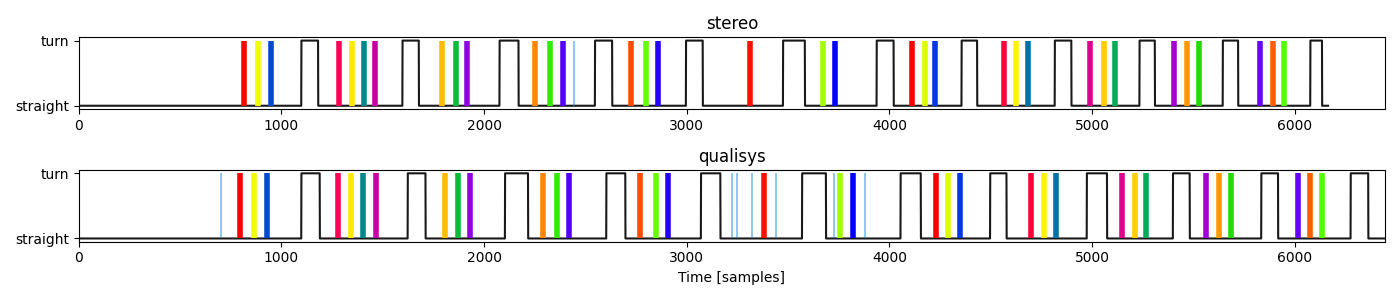

In [61]:
Pair = RecordingPair(folder_path=base_path)

In [ ]:
Pair.print_statistics_results()

In [ ]:
# PLOT KNEE ANGLES
plt.close('all')
fig, axs = plt.subplots(2,2, figsize=(14,6))
for ax_idx, perspective in enumerate(["front", "back"]):
    # stereo_angles = [gc.knee_ext_angles for gc in Pair.stereo.gait_cycles if gc.flags.valid and gc.perspective==perspective]
    # qualisys_angles = [gc.knee_ext_angles for gc in Pair.qualisys.gait_cycles if gc.flags.valid and gc.perspective==perspective]
    stereo_angles = [gc.knee_ext_angles for gc in Pair.sync_pairs[:,0] if gc.flags.valid and gc.perspective==perspective]
    qualisys_angles = [gc.knee_ext_angles for gc in Pair.sync_pairs[:,1] if gc.flags.valid and gc.perspective==perspective]
    for stereo, qualisys in zip(stereo_angles, qualisys_angles) :
        axs[ax_idx,0].plot(stereo)
        axs[ax_idx,1].plot(qualisys)
    axs[ax_idx][0].set_title(perspective)
    axs[ax_idx][1].set_title(perspective)
    axs[ax_idx][0].set_ylim([0,70])
    axs[ax_idx][1].set_ylim([0,70])
    axs[ax_idx][0].grid()
    axs[ax_idx][1].grid()

plt.tight_layout()


In [ ]:
# PLOT SHOULDER FLEX ANGLES
plt.close('all')
fig, axs = plt.subplots(2,2, figsize=(14,6))
for ax_idx, perspective in enumerate(["front", "back"]):
    # stereo_angles = [gc.shoulder_flex_angles for gc in Pair.stereo.gait_cycles if gc.flags.valid and gc.perspective==perspective]
    # qualisys_angles = [gc.shoulder_flex_angles for gc in Pair.qualisys.gait_cycles if gc.flags.valid and gc.perspective==perspective]
    stereo_angles = [gc.shoulder_flex_angles for gc in Pair.sync_pairs[:,0] if gc.flags.valid and gc.perspective==perspective]
    qualisys_angles = [gc.shoulder_flex_angles for gc in Pair.sync_pairs[:,1] if gc.flags.valid and gc.perspective==perspective]
    for stereo, qualisys in zip(stereo_angles, qualisys_angles):
        axs[ax_idx,0].plot(stereo)
        axs[ax_idx,1].plot(qualisys)
    axs[ax_idx][0].set_title(perspective)
    axs[ax_idx][1].set_title(perspective)
    axs[ax_idx][0].grid()
    axs[ax_idx][1].grid()

plt.tight_layout()


In [ ]:
# PLOT ELBOW FLEX ANGLES
plt.close('all')
fig, axs = plt.subplots(2,2, figsize=(14,6))
for ax_idx, perspective in enumerate(["front", "back"]):
    # stereo_angles = [gc.elbow_flex_angles for gc in Pair.stereo.gait_cycles if gc.flags.valid and gc.perspective==perspective]
    # qualisys_angles = [gc.elbow_flex_angles for gc in Pair.qualisys.gait_cycles if gc.flags.valid and gc.perspective==perspective]
    stereo_angles = [gc.elbow_ext_angles for gc in Pair.sync_pairs[:,0] if gc.flags.valid and gc.perspective==perspective]
    qualisys_angles = [gc.elbow_ext_angles for gc in Pair.sync_pairs[:,1] if gc.flags.valid and gc.perspective==perspective]
    for stereo, qualisys in zip(stereo_angles, qualisys_angles):
        axs[ax_idx,0].plot(stereo)
        axs[ax_idx,1].plot(qualisys)
    axs[ax_idx][0].set_title(perspective)
    axs[ax_idx][1].set_title(perspective)
    axs[ax_idx][0].grid()
    axs[ax_idx][1].grid()

plt.tight_layout()

In [ ]:
# CHECK 2D KEYPOINT LOCATIONS/INDICES
video_path = f"stereo_videos\\validation_test\\{participant}\\{paradigm}\\43916681.avi"
loaded_data = np.load(".\\filter_test_3d.npz")
stereo_keypoints = filter_2d_keypoints_butter(loaded_data['keypoints_2d'])
stereo_labels = loaded_data['labels'].tolist()
cap = cv2.VideoCapture(video_path)
if cap.isOpened() == False:
    print("Error opening video file")

frame_idx = 0

# Read until video is completed
while cap.isOpened() and frame_idx < stereo_keypoints.shape[0] - 1:

    # Capture frame-by-frame
    ret, frame = cap.read()

    if ret == True and frame is not None:
        frame_idx += 1
        h, w = frame.shape[:2]

        for kpt_idx, kpt in enumerate(stereo_keypoints[frame_idx, :, :]):
            # highlight certain keypoints in green
            if kpt_idx in [
                stereo_labels.index("left_ankle"),
                stereo_labels.index("right_ankle"),
                stereo_labels.index("left_elbow"),
                stereo_labels.index("right_elbow"),
                stereo_labels.index("left_shoulder"),
                stereo_labels.index("right_shoulder"),
                stereo_labels.index("left_wrist"),
                stereo_labels.index("right_wrist"),
                stereo_labels.index("left_knee"),
                stereo_labels.index("right_knee"),
                stereo_labels.index("left_hip"),
                stereo_labels.index("right_hip"),
                stereo_labels.index("mid_hip"),
                stereo_labels.index("mid_shoulder"),
            ]:
                color = (0, 255, 0)
            else:
                color = (0, 0, 255)
            cv2.circle(frame, (int(kpt[0]), int(kpt[1])), radius=3, color=color, thickness=2)
        cv2.imshow("Image", cv2.resize(frame, (int(w / 1.5), int(h / 1.5))))
        time.sleep(0.01)

        # Press Q on keyboard to exit
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    else:
        break
cap.release()
cv2.destroyAllWindows()

# WIP

## sync rework

### Turns & perspective & segments rework

In [ ]:
self = Pair.stereo

min_peak_height = 0.25
relative_height = 0.85
min_walk_duration = 2

# get the y coord of shoulders (for qualisys x-y plane is horizontal, y coord was forwards/backwards movement)
shoulder_R = self.keypoints[self.labels.index("right_shoulder"), 1, :]
shoulder_L = self.keypoints[self.labels.index("left_shoulder"), 1, :]

# normalize signal
shoulder_diff = np.abs(np.diff(shoulder_R - shoulder_L, prepend=(shoulder_R - shoulder_L)[0]))
shoulder_diff = shoulder_diff / np.nanmax(shoulder_diff)

# Interpolate NaNs in shoulder_diff
if np.any(np.isnan(shoulder_diff)):
    nans = np.isnan(shoulder_diff)
    shoulder_diff[nans] = np.interp(
        np.flatnonzero(nans), np.flatnonzero(~nans), shoulder_diff[~nans]
    )

# min distance from peak to peak (2 seconds of straight movement) in samples
min_peak_distance = min_walk_duration * self.fps

peaks, peak_properties = find_peaks(
    shoulder_diff, height=min_peak_height, distance=min_peak_distance
)
widths, width_heights, left_ips, right_ips = peak_widths(
    x=shoulder_diff, peaks=peaks, rel_height=relative_height
)

# create mask to indicate straight walking segments (straight=False, turn=True)
turn_mask = np.zeros_like(shoulder_R)
for left_base_idx, right_base_idx in zip(
    np.floor(left_ips).astype(int), np.ceil(right_ips).astype(int)
):
    # turn_segment_length = right_base_idx - left_base_idx
    turn_mask[left_base_idx:right_base_idx] = 1

# create mask to indicate front vs back perspectives (front=True, back=False)
perspective = np.where(shoulder_L > shoulder_R, "front", "back")
turn_mask = np.where(turn_mask == 1, "turn", "straight")

# assign indices to straight segments
numeric_perspective = np.where(shoulder_L > shoulder_R,1,0)
perspective_change = np.diff(a=numeric_perspective, prepend=[numeric_perspective[0]])
segment_idx = 0
segment_idices = np.empty_like(perspective_change)
for frame_idx, change in enumerate(perspective_change):
    if change != 0:
        segment_idx += 1
    segment_idices[frame_idx] = segment_idx

# record boundary indices of segments
segment_boundary_indices = np.concat(([0],np.flatnonzero(perspective_change),[len(perspective_change)]))
segment_boundaries = {}
for idx, boundary in enumerate(segment_boundary_indices):
    if idx < len(segment_boundary_indices)-1:
        segment_boundaries[idx] = [boundary, segment_boundary_indices[idx+1]]
# ====================================================================PLOT========================================================================
if True:
    plt.close("all")
    fig, axs = plt.subplots(4, 1, figsize=(14, 6))

    axs[0].plot(shoulder_diff, label="shoulder diff")
    axs[0].plot(left_ips, width_heights, "o", label="turn start", markersize=4)
    axs[0].plot(right_ips, width_heights, "o", label="turn end", markersize=4)
    axs[0].plot(turn_mask, label="straight/turn")
    axs[0].set_title("turn mask")

    axs[1].plot(shoulder_L, label="left")
    axs[1].plot(shoulder_R, label="right")
    axs[1].set_title("shoulder position (horizontal)")

    axs[2].plot(perspective, label="perspective")

    axs[2].set_title("Perspective")
    
    axs[3].plot(segment_idices, label="segment indices")
    axs[3].set_title("segment indices")
    axs[3].set_xlabel("Time [samples]")

    for ax in axs[:-2]:
        ax.legend(loc="upper left")
        ax.grid()

    plt.tight_layout()

In [ ]:
frame = 1362
for segment_idx, (start, end) in segment_boundaries.items():
    if start < frame < end:
        print(segment_idx)

In [ ]:
segment_boundaries

### sync

In [49]:
Pair.sync_shift, Pair.stereo.keypoints.shape[2], Pair.qualisys.keypoints.shape[2], Pair.stereo.keypoints.shape[2]- Pair.qualisys.keypoints.shape[2] 

(np.int64(364), 6413, 6336, 77)

In [51]:
self = Pair
gc_pairs = []
stereo_first_turn = np.where(self.stereo.turn_mask == "turn")[0][0]
qualisys_first_turn = np.where(self.qualisys.turn_mask == "turn")[0][0]
shift = stereo_first_turn - qualisys_first_turn

qualisys_gcs = np.copy(self.qualisys.gait_cycles).tolist()
for gc in self.stereo.gait_cycles:

    potential_pairs = [
        p
        for p in qualisys_gcs
        if p.segment_index == gc.segment_index
        and p.ipsi == gc.ipsi
        and p.perspective == gc.perspective
    ]

    # there are potential pair found
    if len(potential_pairs) != 0:

        if gc.segment_index != 0:
            # calculate difference between relative positions (position within segment), choose closest one
            best_pair_idx = np.argmin(
                [abs(gc.relative_position - p.relative_position) for p in potential_pairs]
            )
        else: 
            # calculate difference between absolute positions. 
            # Needed since recordings start at different times, first segments have different lengths which throws off relative calculaiton. 
            stereo_segment_end = self.stereo.segment_boundaries[0][1]
            stereo_absolute_position = stereo_segment_end - gc.IC0.frame

            qualisys_segment_end = self.qualisys.segment_boundaries[0][1]
            best_pair_idx = np.argmin(
                [abs(stereo_absolute_position - (qualisys_segment_end - p.IC0.frame)) for p in potential_pairs]
            )

        choosen_pair = potential_pairs[best_pair_idx]
        gc_pairs.append([gc, choosen_pair])
        # remove choosen pair from pool potential pairs of the rest
        qualisys_gcs.remove(choosen_pair)
    print(gc.IC0.frame,round(gc.relative_position,2), [p.IC0.frame for p in potential_pairs], [round(abs(p.relative_position),2) for p in potential_pairs], best_pair_idx)

1214 0.29 [828, 988, 1132] [np.float64(0.39), np.float64(0.27), np.float64(0.16)] 0
1297 0.24 [913, 1059] [np.float64(0.33), np.float64(0.22)] 0
1367 0.2 [988, 1132] [np.float64(0.27), np.float64(0.16)] 0
1438 0.16 [1059] [np.float64(0.22)] 0
1509 0.12 [1132] [np.float64(0.16)] 0
1865 0.77 [1504, 1658, 1818] [np.float64(0.78), np.float64(0.55), np.float64(0.32)] 0
1940 0.65 [1585, 1729] [np.float64(0.66), np.float64(0.45)] 0
2012 0.54 [1658, 1818] [np.float64(0.55), np.float64(0.32)] 0
2081 0.43 [1729] [np.float64(0.45)] 0
2150 0.33 [1818] [np.float64(0.32)] 0
2535 0.74 [2223, 2347] [np.float64(0.72), np.float64(0.54)] 0
2610 0.62 [2277, 2418] [np.float64(0.64), np.float64(0.44)] 0
2678 0.52 [2347] [np.float64(0.54)] 0
2750 0.41 [2418] [np.float64(0.44)] 0
2815 0.31 [] [] 0
3181 0.75 [2867, 3019, 3178] [np.float64(0.77), np.float64(0.54), np.float64(0.3)] 0
3259 0.63 [2946, 3089] [np.float64(0.65), np.float64(0.44)] 0
3390 0.43 [3089] [np.float64(0.44)] 0
3508 0.25 [3019, 3178] [np.flo

C:\Users\munger\AppData\Local\Temp\ipykernel_1178748\1469314416.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("prism", int(len(gc_pairs)))


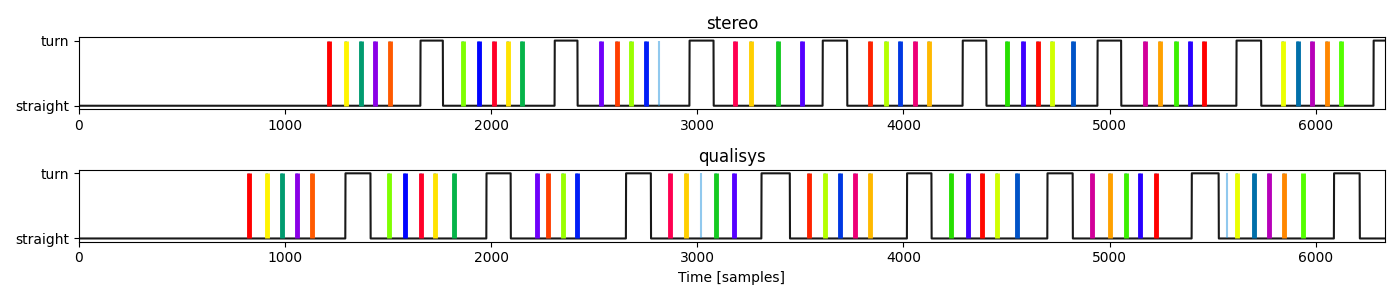

In [52]:
plt.close("all")
fig, axs = plt.subplots(2, 1, figsize=(14, 3))

# plot turn masks
axs[0].plot(self.stereo.turn_mask[:], color="#000000", alpha=0.9,linestyle='-')
axs[1].plot(self.qualisys.turn_mask, color="#000000", alpha=0.9,linestyle='-')

# plot valid GCs for both recording types
for stereo_gc, qualisys_gc in zip(self.stereo.gait_cycles, self.qualisys.gait_cycles):
    axs[0].vlines(x=stereo_gc.IC0.frame, ymin=0, ymax=1, color="#138BDB76")
    axs[1].vlines(x=qualisys_gc.IC0.frame, ymin=0, ymax=1, color="#138BDB76")

# plot pairs 
colors = plt.cm.get_cmap("prism", int(len(gc_pairs)))
for color_idx, (stereo_gc, qualisys_gc) in enumerate(gc_pairs): 
    axs[0].vlines(x=stereo_gc.IC0.frame, ymin=0, ymax=1, color=colors(color_idx), linewidth=3.5)
    axs[1].vlines(x=qualisys_gc.IC0.frame, ymin=0, ymax=1, color=colors(color_idx), linewidth=3.5)

axs[0].set_title("stereo")
axs[1].set_title("qualisys")
axs[0].set_xlim([0, self.qualisys.keypoints.shape[2]])
axs[1].set_xlim([0, self.qualisys.keypoints.shape[2]])
axs[1].set_xlabel("Time [samples]")

plt.tight_layout()

In [16]:
for s, q in Pair.sync_pairs:
    print(s.IC0.frame, q.IC0.frame)

1214 988
1297 1059
1367 1132
1438 913
1509 828
1865 1504
1940 1585
2012 1658
2081 1729
2150 1818
2535 2223
2610 2277
2678 2347
2750 2418
3181 2867
3259 2946
3390 3089
3508 3178
3840 3540
3916 3622
3984 3694
4056 3766
4126 3839
4504 4230
4582 4312
4653 4383
4721 4454
4825 4550
5170 4917
5246 5003
5321 5078
5388 5149
5458 5223
5839 5620
5912 5703
5984 5774
6053 5846
6125 5938


In [37]:
Pair.sync_shift

np.int64(364)

In [ ]:
len(gc_pairs)

### Add segment index to GEs and GCs

In [ ]:
Pair.stereo.gait_cycles[10].gait_events

In [ ]:
Pair.stereo.turn_mask.shape, Pair.stereo.keypoints.shape

In [ ]:
plt.close('all')
fig, axs = plt.subplots(1,1,figsize=(14,2))
axs.plot(self.stereo.turn_mask)
axs.plot(turn_change)
axs.plot(segment_idices)

plt.tight_layout()

In [ ]:
self.stereo.keypoints.shape, turn_change.shape

In [ ]:
segment_start = np.where(segment_idices==2)[0][0]
segment_end = np.where(segment_idices==2)[0][-1]
print(segment_start, segment_end)

f = 2290

(f-segment_start)/(segment_end-segment_start)

In [ ]:
self = Pair
gc_pairs = []

stereo_first_turn = np.where(self.stereo.turn_mask=="turn")[0][0]
qualisys_first_turn = np.where(self.qualisys.turn_mask=="turn")[0][0]
shift = stereo_first_turn - qualisys_first_turn

# get start and end frame indices of straight segments for stereo recording
numeric_mask = np.where(self.stereo.turn_mask=='turn',1,0)
turn_change = np.diff(a=numeric_mask, prepend=[numeric_mask[0]])

# assign indices to straight segments
segment_idx = 0
segment_idices = np.empty_like(turn_change)
for frame_idx, change in enumerate(turn_change):
    if change == 1:
        segment_idx += 1
    segment_idices[frame_idx] = segment_idx

## resample fix


In [ ]:
print(keypoints_3d.shape)
for l_idx, l in enumerate(stereo_labels):
    print(l_idx, l)

In [ ]:
target_fps = 100
original_fps = 60
original_num_frames = keypoints_3d.shape[0]
target_num_frames = int(np.round(original_num_frames * target_fps / original_fps))
# resampled_keypoints = resample(keypoints_3d, target_num_frames, axis=0)
resampled_keypoints = resample_timeseries(keypoints_3d=keypoints_3d,original_fps=original_fps, target_fps=target_fps)


# PLOTTING
kpt_idx = 5
plt.close('all')
fig, axs = plt.subplots(6,1, figsize=(14,9))
axs[0].plot(keypoints_3d[:,kpt_idx,0], label="60 Hz", c='r')
axs[2].plot(keypoints_3d[:,kpt_idx,1], label="60 Hz", c='g')
axs[4].plot(keypoints_3d[:,kpt_idx,2], label="60 Hz", c='b')

axs[1].plot(resampled_keypoints[:,kpt_idx,0], label="100 Hz", c='r')
axs[3].plot(resampled_keypoints[:,kpt_idx,1], label="100 Hz", c='g')
axs[5].plot(resampled_keypoints[:,kpt_idx,2], label="100 Hz", c='b')

for ax in axs:
    ax.legend(loc="lower right")

plt.tight_layout()

## sync fix

In [ ]:
[gc for gc in Pair.qualisys.gait_cycles if gc.flags.valid]

In [ ]:
self = Pair
window=70


gc_pairs = []

stereo_first_turn = np.where(self.stereo.turn_mask=="turn")[0][0]
qualisys_first_turn = np.where(self.qualisys.turn_mask=="turn")[0][0]
shift = stereo_first_turn - qualisys_first_turn
# shift = self.stereo.gait_events[0].frame - self.qualisys.gait_events[0].frame

for gc in self.stereo.gait_cycles:
    if gc.flags.valid:
        sync_frame = gc.IC0.frame - shift

        potential_pairs = [
            p
            for p in self.qualisys.gait_cycles
            if abs(p.IC0.frame - sync_frame) < window
            and p.flags.valid
            and p.ipsi == gc.ipsi
            and p.perspective == gc.perspective
            and p.IC0.frame + shift + 40 >= gc.IC0.frame
        ]
        if len(potential_pairs) != 0:
            gc_pairs.append([gc, potential_pairs[0]])

        print(sync_frame, potential_pairs)

In [ ]:
stereo_first_turn = np.where(self.stereo.turn_mask=="turn")[0][0]
qualisys_first_turn = np.where(self.qualisys.turn_mask=="turn")[0][0]
print(stereo_first_turn)
print(qualisys_first_turn)
print(stereo_first_turn-qualisys_first_turn)

## Study statistics

In [ ]:
# CREATE STUDY RESULTS CONTAINER
nested_dict = lambda: defaultdict(nested_dict)
aggregated_results = nested_dict()
for perspective in ["front", "back"]:
    for recording_type in ["qualisys", "stereo"]:
        for parameter in GAIT_PARAMETERS:
            for metric in ["mean", "cv", "asymmetry"]:
                aggregated_results[perspective][recording_type][parameter][metric] = []

In [ ]:
# FILL CONTAINER
resutlt_paths = [g for g in glob.glob(".\\filter_test_data\\*.json")]
for path in resutlt_paths:
    with open(path, 'r') as f:
        pair_results = json.load(f)

        for perspective in ["front", "back"]:
            for recording_type in ["qualisys", "stereo"]:
                for parameter in GAIT_PARAMETERS:
                    for metric in ["mean", "cv", "asymmetry"]:
                        aggregated_results[perspective][recording_type][parameter][metric].append(
                            pair_results[perspective][recording_type][parameter][metric]
                        )


In [ ]:
for perspective, pair_values in aggregated_results.items():
    # print(perspective, pair_values)
    stereo_results = pair_values['stereo']
    qualisys_results = pair_values['qualisys']
    for parameter in GAIT_PARAMETERS:
        stereo_parameter_results = stereo_results[parameter]
        qualisys_parameter_resutls = qualisys_results[parameter]

        for metric in ['mean','cv','asymmetry']:
            stereo_metrics = stereo_parameter_results[metric]
            qualisys_metrics = qualisys_parameter_resutls[metric]
            uni = uniform_statistics(qualisys_metrics, stereo_metrics)
            print(perspective, parameter, metric)
            break
        break
    break

In [ ]:
uni

## check gait cycles

In [ ]:
fig= plt.figure(figsize=(14,3))

gait_events = Pair.stereo.gait_events

for ge in gait_events:
    alpha = 1 if ge.segment=='straight' else 0.2
    color = "#55e05c" if ge.type=='IC' else "#5565e0"
    match ge.side:
        case 'left':
            plt.vlines(x=ge.frame, ymin=0, ymax=1, alpha=alpha, colors=color)
        case 'right':
            plt.vlines(x=ge.frame, ymin=-1, ymax=0, alpha=alpha, colors=color)

plt.tight_layout()

In [ ]:
for gc_idx, gc in enumerate(Pair.stereo.gait_cycles):
    print(gc_idx)
    print(gc)
    print(gc.flags)
    for ge, pge in zip(gc.gait_events, gc.possible_gait_events):
        print(f"{ge} | {pge}")
    print(f"IC0: {gc.IC0}")
    print(f"FC0: {gc.FC0}")
    print(f"IC1: {gc.IC1}")
    print(f"FC1: {gc.FC1}")
    print(f"IC2: {gc.IC2}")
    
    print('')
    print('')

### Bokeh

In [ ]:
tuple(np.random.randint(low=0, high=255,size=(3)))

In [ ]:
color = LinearColorMapper(palette = "Magma256", low = 0, high = 1)
color.

In [ ]:
# importing the modules 
import itertools
import bokeh
from bokeh.plotting import figure, output_file, show 
from bokeh.models import LinearColorMapper

bokeh.io.output_notebook()

# file to save the model 
# output_file("gfg.html") 
# colors = itertools.cycle(Category10[len(Pair.stereo.gait_cycles)])

color = LinearColorMapper(palette = "Magma256", low = 0, high = 10)
# instantiating the figure object 
graph = figure(title = "Bokeh Hiding Glyphs",sizing_mode="stretch_width", max_width=1500, height=250) 
graph.graph
for gc_idx, gc in enumerate(Pair.stereo.gait_cycles):
    # color = tuple(np.random.randint(low=0, high=100,size=(3)))
    for ge in gc.possible_gait_events:
        graph.vbar(x=ge.frame, top=1, width=1, legend_label=f"{gc_idx}", muted_alpha=0.2)

# for ge in Pair.stereo.gait_events:
#     graph.vbar(x=ge.frame, top=1, width=1, color="violet", legend_label=f"ic", muted_alpha=0.2)


# enable hiding of the glyphs 
graph.legend.click_policy = "mute"

# displaying the model 
show(graph)